# Лабораторна 2. Від сирих даних до нейромережі

У цій лабораторній роботі ви пройдете повний цикл роботи з табличним датасетом для задачі регресії - від завантаження до порівняння моделей:

- дослідницький аналіз даних (EDA): загальний огляд, гістограми, кореляції;
- обробка пропусків і викидів;
- інженерія ознак;
- baseline: множинна лінійна регресія;
- нейромережа - підбір архітектури, функцій активації, оптимізатора власними експериментами;
- чесне порівняння моделей на test за метриками регресії (MSE, RMSE, MAE, R²).

Демо-ноутбук з лекції 3-4 - основа, звертайтесь до нього як до довідника, коли щось незрозуміло.

## 0. Опрацюйте демо-ноутбук з лекції
Прогляньте пояснення ноутбуку і запустіть всі клітинки демо-ноутбуку (крім тих секцій, в яких вказано, що їх запускати не можна).
Після цього дайте тут відповідь на запитання:
1. Чому для заповнення пропусків було обрано метод kNN?
2. Чому при тренуванні лінійної регресії train і val порівнюються лише на основі MSE, а після тренування на основі багатьох функцій? Проекспериментуйте в межах тренування з вибором функції і поділіться результатами.
3. Які висновки після клітинки 2.6 в демо Ви можете зробити?
4. Поясни для чого потрібен baseline в лінійній регресії і як він вираховується? Що є baseline для нейронної мережі?
5. Продемонструй дію всіх функцій активації на графіку функцій, згенерувавши 1000 випадкових значень Х і порахувавши для них Y через ці функції.
6. Яким чином в нейронній мережі утворилася така кількість параметрів, яка вказана після виконання 3.3?
7. Чи оптимально вибрано кількість епох в 3.5?

### 0.1 Мої відповіді:

Для заповнення пропусків обрали kNN, бо звичайна підстановка середнього чи медіани тупо рахує кожну колонку окремо і повністю втрачає зв'язок між іншими даними. kNN натомість дивиться на сусідні схожі рядки і підставляє адекватне значення. При цьому моделі kNN навчали виключно на train, щоб не було витоку даних у val і test.

Під час тренування порівнюють тільки по MSE, бо градієнтному спуску потрібна гладка диференційована функція втрат для швидкого оновлення ваг. Після тренування вже рахують MAE, RMSE та R2, щоб бачити реальну похибку в грошах та зрозуміти наскільки модель взагалі краща за тупе вгадування середнього. При експерименті з L1Loss лосс біля мінімуму починає смикатися і сходиться гірше за MSE.

Після клітинки 2.6 видно, що оскільки ознаки стандартизували до однакового масштабу, по величині ваг можна судити про силу їхнього впливу на ціну. Найбільшу вагу мав дохід MedInc, що логічно, а створена просторова ознака diag_coord отримала помітну вагу і довела свою користь.

Бейзлайн потрібен як точка відліку, щоб розуміти чи складна модель взагалі дає користь. Для лінійної регресії бейзлайн - це тупо видавати середнє значення ціни по train (тоді R2 = 0), і якщо модель дає гірше, вона непридатна. Для нейромережі бейзлайном виступає лінійна регресія: якщо сітка не може перебити пряму лінію, то щось пішло не так. Демонстрація функцій активації на 1000 точках наведена на графіку нижче.

Кількість параметрів у 3.3 порахована так: на вході 7 ознак, перший шар Linear(7, 64) дає 7*64 ваг + 64 зсуви = 512, другий шар Linear(64, 32) дає 64*32 + 32 = 2080, вихідний шар Linear(32, 1) дає 32*1 + 1 = 33, а ReLU параметрів не має. Разом 512 + 2080 + 33 = 2625 параметрів, що приблизно у 330 разів більше за лінійну регресію, де було лише 8 параметрів.

200 епох у 3.5 вибрано не оптимально, це забагато. По графіку видно, що десь після 80-100 епох валідаційний лосс виходить на плато і майже не падає, тому далі вчити немає сенсу, щоб не зловити перенавчання.


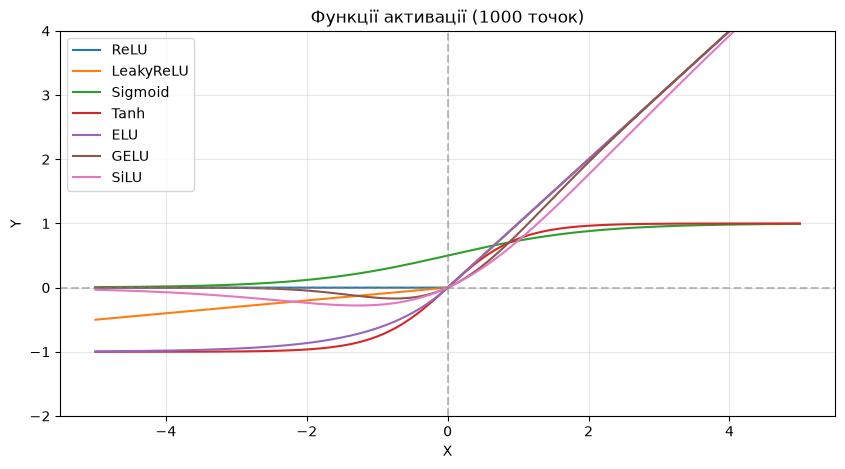

In [10]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

x = torch.linspace(-5, 5, 1000)

funcs = {
    "ReLU": nn.ReLU(),
    "LeakyReLU": nn.LeakyReLU(0.1),
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
    "ELU": nn.ELU(),
    "GELU": nn.GELU(),
    "SiLU": nn.SiLU()
}

plt.figure(figsize=(10, 5))
for name, f in funcs.items():
    plt.plot(x.numpy(), f(x).numpy(), label=name)

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.title("Функції активації (1000 точок)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-2, 4)
plt.show()


---
## 1. Датасети

Ви отримаєте один з 10 датасетів нижче. Усі - задачі регресії на Hugging Face: табличні дані, здебільшого числові ознаки, від кількасот до кількадесяти тисяч рядків.

1. **[King County House Sales](https://huggingface.co/datasets/kraina/house_sales_in_king_county)** - 21 613 продажів будинків (Вашингтон, 2014-2015). Таргет: `price`. ⚠️ `load_dataset("kraina/house_sales_in_king_county")` не працює (застарілий loading-скрипт) - вантажте напряму: `load_dataset("parquet", data_files="https://huggingface.co/datasets/kraina/house_sales_in_king_county/resolve/main/data/house_sales_king_county.parquet")`.
2. **[Diamonds](https://huggingface.co/datasets/jdxcosta/diamonds)** - 53 940 діамантів. Таргет: `price`. Ознаки: вага (`carat`), огранка, колір, чистота, розміри.
3. **[Concrete Compressive Strength](https://huggingface.co/datasets/foundry-ml/dataset_concrete_compressive_strength)** - 1 030 замісів бетону. Таргет: міцність на стиск. Усі ознаки числові (склад суміші + вік).
4. **[Auto MPG](https://huggingface.co/datasets/scikit-learn/auto-mpg)** - 398 автомобілів. Таргет: `mpg` (витрата пального). Найменший і найпростіший датасет зі списку.
5. **[Wine Quality](https://huggingface.co/datasets/codesignal/wine-quality)** - 1 599 (червоне) + 4 898 (біле) вин. Таргет: `quality` (оцінка 3-9). Усі ознаки - хімічний склад, числові.
6. **[Laptop Price](https://huggingface.co/datasets/Ammok/laptop_price_prediction)** - 977 + 325 ноутбуків. Таргет: `Price`. Частина ознак текстові (`RAM`, `Storage`, `CPU`) - доведеться парсити в числа.
7. **[Bike Sharing Demand](https://huggingface.co/datasets/t22000t/bike-sharing-tabular)** - 17 379 годинних записів прокату велосипедів. Таргет: `cnt`. Часові й погодні ознаки.
8. **[Ames House Prices](https://huggingface.co/datasets/t22000t/house-prices-tabular)** - 1 460 будинків, 79 ознак. Таргет: `SalePrice`. Найбільше категоріальних ознак зі списку - гарна практика на encoding.
9. **[Medical Insurance Cost](https://huggingface.co/datasets/harishsohani/medical-insurance-cost-prediction)** - 1 338 застрахованих. Таргет: `charges`. Компактний, мало ознак - хороший старт, якщо часу мало. ⚠️ У репозиторії кілька CSV одразу (`Xtrain`/`Xtest`/`insurance.csv`) - вкажіть файл явно: `load_dataset("harishsohani/medical-insurance-cost-prediction", data_files="insurance.csv")`.
10. **[Abalone](https://huggingface.co/datasets/mstz/abalone)** - 4 177 молюсків. Таргет: `number_of_rings` (вік). Усі ознаки - фізичні виміри, окрім `sex`.

Решта (2-5, 7-8, 10) вантажаться напряму - `load_dataset("<repo_id>")` без додаткових аргументів, HF-токен не потрібен.

### 1.1. Який датасет мій?

Визначте самі власний датасет: беремо Ваше ПІБ, рахуємо SHA-256 хеш, залишок від ділення на 10 - це індекс у списку датасетів вище (0 → перший, 9 → останній).

**Формат ПІБ:** точно як у списку групи - `Прізвище Ім'я По-батькові`, по одному пробілу між словами, без зайвих пробілів на початку/в кінці. Якщо використаєте інший формат - **не зарахую лабу**!!!

In [11]:
import hashlib

DATASETS = [
    "King County House Sales",
    "Diamonds",
    "Concrete Compressive Strength",
    "Auto MPG",
    "Wine Quality",
    "Laptop Price",
    "Bike Sharing Demand",
    "Ames House Prices",
    "Medical Insurance Cost",
    "Abalone",
]

FULL_NAME = "Горбачов Олег Андрійович"

dataset_index = int(hashlib.sha256(FULL_NAME.encode("utf-8")).hexdigest(), 16) % len(DATASETS)
print(f"Ваш датасет (#{dataset_index + 1}):", DATASETS[dataset_index])


Ваш датасет (#6): Laptop Price


---
## 2. Що потрібно зробити

Нижче - загальний план роботи, без коду: код і пояснення до кожного кроку дивіться в **демо-ноутбуці лекції 3-4**, номери розділів позначені в дужках. Ваша задача - повторити той самий підхід на своєму датасеті, а не скопіювати код один в один: у вашого датасету інші колонки, інші типи пропусків (чи їх взагалі нема), інші викиди (чи їх нема) - рішення на кожному кроці обґрунтовуйте під свої дані, а не тому, що "так було в демо".

### 2.1. Підготовка даних

1. Завантажте свій датасет (демо 1.1) і перетворіть на `pandas.DataFrame` (1.2).
2. Зробіть спліт **train / val / test** одразу, до будь-якого аналізу (1.3) - і поясніть своїми словами, чому саме в такому порядку (нагадування: data leakage).
3. Загальний огляд (`head`/`info`/`describe`, 1.4).
4. Обробка пропусків (1.5) - **якщо вони є**. Немає пропусків - так і напишіть, це теж валідний результат, не треба їх штучно вигадувати.
5. EDA (1.6): хоча б гістограми і кореляційна матриця. Що впадає в очі у ваших даних - capping, скошені розподіли, мультиколінеарність?
6. Обробка викидів (1.7) - **за потреби**, з обґрунтуванням: звідки взявся викид і чому саме таке рішення (видалити / трансформувати / залишити).
7. Інженерія ознак (1.8) - **за потреби**: чи є сенс комбінувати/прибирати ознаки з високою кореляцією між собою.

### 2.2. Baseline: множинна лінійна регресія

Стандартизація ознак (2.1), тензори (2.2), тренування `nn.Linear` (2.3), крива навчання (2.4), метрики на test - MSE/RMSE/MAE/R² (2.5), інтерпретація ваг (2.6).

Це ваш **варіант #1**, точка відліку для всього, що далі.

### 2.3. Нейромережа: щонайменше 2 різні архітектури

За зразком розділу 3 демо: `nn.Sequential` з прихованими шарами, ReLU, оптимізатор Adam.

Спробуйте **мінімум 2 архітектури**, які відрізняються не косметично - напр. різна кількість шарів, різна ширина шарів, чи інша функція активації (3.2). Кожна - окремий варіант.

### 2.4. Підбір гіперпараметрів: щонайменше 3 зміни

Візьміть архітектуру, яка показала себе краще, і поекспериментуйте з гіперпараметрами: learning rate, оптимізатор (SGD/Adam), кількість епох, розмір batch (якщо вирішите його ввести) тощо. Змінюйте **по одному параметру за раз** - інакше не зрозумієте, що саме вплинуло на результат.

**Разом (2.2 + 2.3 + 2.4):** щонайменше 5 варіантів моделі (1 лінійна + 2 архітектури + 2 гіперпараметри), до **10 варіантів** - якщо є час і бажання поекспериментувати більше, це тільки заохочується.

### 2.5. Логування і порівняння

Кожен варіант (2.2-2.4) логуйте в TensorBoard в окрему підпапку `RUNS_DIR` (як у 2.3/3.5 демо) - з осмисленою назвою (`linear`, `nn_v1_2layers`, `nn_v2_deeper`, `nn_v2_lr_0.001`, ...), щоб потім усі криві можна було накласти одна на одну (3.8 демо) і візуально порівняти.

Наприкінці зведіть усі варіанти в одну таблицю (модель → MSE/RMSE/MAE/R² на test) і дайте коротку письмову відповідь:
- Яка модель перемогла і наскільки суттєво?
- Чи виправдала себе нейромережа порівняно з лінійною регресією на вашому датасеті?
- Що з ваших змін (архітектура чи гіперпараметри) дало найбільший ефект?

In [12]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torch.utils.tensorboard import SummaryWriter

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Завантажуємо Laptop Price з Hugging Face
ds = load_dataset("Ammok/laptop_price_prediction")
raw_df = pd.concat([ds["train"].to_pandas(), ds["test"].to_pandas()], ignore_index=True)
raw_df.columns = [c.strip() for c in raw_df.columns]

# Спліт одразу, щоб не було data leakage (70% train, 15% val, 15% test)
train_raw, temp_raw = train_test_split(raw_df, test_size=0.30, random_state=SEED)
val_raw, test_raw = train_test_split(temp_raw, test_size=0.50, random_state=SEED)

print("Розміри вибірок:", len(train_raw), len(val_raw), len(test_raw))


Device: cpu
Розміри вибірок: 911 195 196


In [13]:
# Чистимо дані та витягуємо числові фічі
def clean_df(df):
    d = df.copy()
    d['RAM_GB'] = d['RAM'].astype(str).str.extract(r'(\d+)')[0].astype(int)
    d['Weight_kg'] = d['Weight'].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)
    d['Screen_Size_in'] = d['Screen Size'].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)
    
    d['Touchscreen'] = d['Screen'].str.contains('Touchscreen', case=False, na=False).astype(int)
    d['IPS'] = d['Screen'].str.contains('IPS', case=False, na=False).astype(int)
    res = d['Screen'].astype(str).str.extract(r'(\d{3,4})\s*x\s*(\d{3,4})')
    d['PPI'] = (np.sqrt(res[0].astype(float)**2 + res[1].astype(float)**2) / d['Screen_Size_in']).round(1)
    
    d['CPU_Freq'] = d['CPU'].astype(str).str.extract(r'(\d+\.?\d*)\s*GHz')[0].astype(float)
    
    def get_cpu(x):
        s = str(x).lower()
        if 'i7' in s: return 'Intel Core i7'
        if 'i5' in s: return 'Intel Core i5'
        if 'i3' in s: return 'Intel Core i3'
        if 'amd' in s: return 'AMD'
        return 'Other'
    d['CPU_Brand'] = d['CPU'].apply(get_cpu)
    
    def get_storage(x):
        s = str(x).replace('  ', ' ')
        ssd, hdd = 0, 0
        for p in s.split('+'):
            m = re.findall(r'(\d+\.?\d*)\s*(TB|GB)', p, re.I)
            if m:
                val, unit = float(m[0][0]), m[0][1].upper()
                gb = val * 1024 if unit == 'TB' else val
                if 'HDD' in p.upper(): hdd += gb
                else: ssd += gb
        return pd.Series([ssd, hdd], index=['SSD_GB', 'HDD_GB'])
        
    st = d['Storage'].apply(get_storage)
    d['SSD_GB'] = st['SSD_GB']
    d['HDD_GB'] = st['HDD_GB']
    
    def get_gpu(x):
        s = str(x).lower()
        if 'intel' in s: return 'Intel'
        if 'nvidia' in s: return 'Nvidia'
        if 'amd' in s: return 'AMD'
        return 'Other'
    d['GPU_Brand'] = d['GPU'].apply(get_gpu)
    
    def get_os(x):
        s = str(x).lower()
        if 'windows' in s: return 'Windows'
        if 'mac' in s: return 'macOS'
        if 'linux' in s: return 'Linux'
        return 'Other'
    d['OS_Type'] = d['Operating System'].apply(get_os)
    d['Category_Type'] = d['Category'].fillna('Notebook')
    
    cols = ['Price', 'RAM_GB', 'Weight_kg', 'Screen_Size_in', 'Touchscreen', 'IPS', 'PPI',
            'CPU_Freq', 'SSD_GB', 'HDD_GB', 'CPU_Brand', 'GPU_Brand', 'OS_Type', 'Category_Type']
    return d[cols]

train_c = clean_df(train_raw)
val_c = clean_df(val_raw)
test_c = clean_df(test_raw)

# Заповнюємо пропуски медіаною тільки з train
train_c['PPI'] = train_c['PPI'].fillna(train_c['PPI'].median())
train_c['CPU_Freq'] = train_c['CPU_Freq'].fillna(train_c['CPU_Freq'].median())

val_c['PPI'] = val_c['PPI'].fillna(train_c['PPI'].median())
val_c['CPU_Freq'] = val_c['CPU_Freq'].fillna(train_c['CPU_Freq'].median())

test_c['PPI'] = test_c['PPI'].fillna(train_c['PPI'].median())
test_c['CPU_Freq'] = test_c['CPU_Freq'].fillna(train_c['CPU_Freq'].median())

# One-hot encoding
cat_cols = ['CPU_Brand', 'GPU_Brand', 'OS_Type', 'Category_Type']
train_df = pd.get_dummies(train_c, columns=cat_cols, drop_first=True)
feature_cols = [c for c in train_df.columns if c != 'Price']

val_df = pd.get_dummies(val_c, columns=cat_cols, drop_first=True).reindex(columns=train_df.columns, fill_value=0)
test_df = pd.get_dummies(test_c, columns=cat_cols, drop_first=True).reindex(columns=train_df.columns, fill_value=0)

print("Кількість ознак:", len(feature_cols))


Кількість ознак: 24


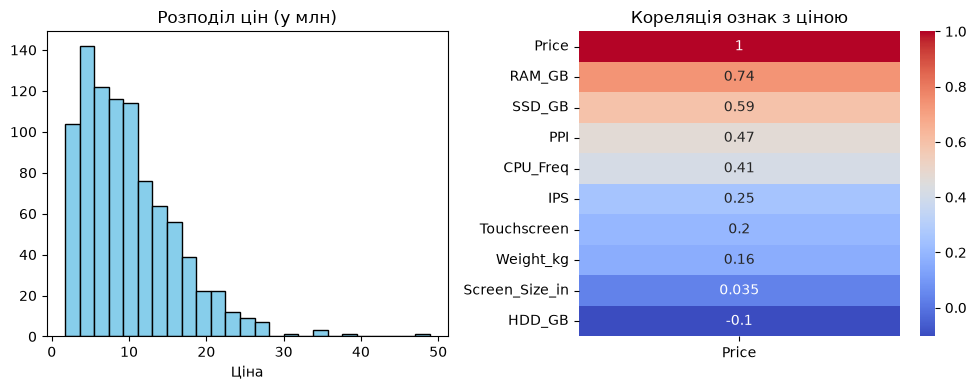

In [14]:
# EDA: розподіл цін і кореляції
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(train_c['Price'] / 1e6, bins=25, edgecolor='black', color='skyblue')
plt.title("Розподіл цін (у млн)")
plt.xlabel("Ціна")

plt.subplot(1, 2, 2)
num_cols = train_c.select_dtypes(include=[np.number]).columns
sns.heatmap(train_c[num_cols].corr()[['Price']].sort_values(by='Price', ascending=False), annot=True, cmap='coolwarm')
plt.title("Кореляція ознак з ціною")
plt.tight_layout()
plt.show()


In [15]:
# 2.2 Baseline: Множинна лінійна регресія
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feature_cols])
X_val = scaler.transform(val_df[feature_cols])
X_test = scaler.transform(test_df[feature_cols])

SCALE = 1e6
y_train = train_df['Price'].values / SCALE
y_val = val_df['Price'].values / SCALE
y_test = test_df['Price'].values / SCALE
y_test_real = test_df['Price'].values

def to_t(X, y):
    return torch.tensor(X, dtype=torch.float32).to(device), torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(device)

x_tr_t, y_tr_t = to_t(X_train, y_train)
x_v_t, y_v_t = to_t(X_val, y_val)
x_te_t, y_te_t = to_t(X_test, y_test)

os.makedirs("models", exist_ok=True)
os.makedirs("runs", exist_ok=True)

linear_model = nn.Linear(len(feature_cols), 1).to(device)
opt_lin = torch.optim.Adam(linear_model.parameters(), lr=0.05)
loss_fn = nn.MSELoss()

writer = SummaryWriter("runs/linear")
tr_losses_lin, val_losses_lin = [], []

for epoch in range(200):
    linear_model.train()
    opt_lin.zero_grad()
    pred = linear_model(x_tr_t)
    loss = loss_fn(pred, y_tr_t)
    loss.backward()
    opt_lin.step()
    tr_losses_lin.append(loss.item())
    
    linear_model.eval()
    with torch.no_grad():
        v_loss = loss_fn(linear_model(x_v_t), y_v_t).item()
    val_losses_lin.append(v_loss)
    writer.add_scalar("Loss/train", loss.item(), epoch)
    writer.add_scalar("Loss/val", v_loss, epoch)

writer.close()
torch.save(linear_model.state_dict(), "models/linear.pt")

linear_model.eval()
with torch.no_grad():
    preds_lin = linear_model(x_te_t).cpu().numpy().flatten() * SCALE

mse_lin = mean_squared_error(y_test_real, preds_lin)
rmse_lin = np.sqrt(mse_lin)
mae_lin = mean_absolute_error(y_test_real, preds_lin)
r2_lin = r2_score(y_test_real, preds_lin)

results = []
results.append({"Model": "linear", "MSE": mse_lin, "RMSE": rmse_lin, "MAE": mae_lin, "R2": r2_lin})
print(f"Linear -> RMSE: {rmse_lin:,.0f}, MAE: {mae_lin:,.0f}, R2: {r2_lin:.4f}")


Linear -> RMSE: 4,192,244, MAE: 3,101,179, R2: 0.6358


In [16]:
# 2.3 Нейромережа (2 архітектури) та 2.4 (гіперпараметри)

# 1. nn_v1: 2 приховані шари (128 -> 64), ReLU
nn_v1 = nn.Sequential(
    nn.Linear(len(feature_cols), 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
).to(device)

opt_v1 = torch.optim.Adam(nn_v1.parameters(), lr=0.01)
writer = SummaryWriter("runs/nn_v1_2layers")
tr_losses_v1, val_losses_v1 = [], []

for epoch in range(200):
    nn_v1.train(); opt_v1.zero_grad(); loss = loss_fn(nn_v1(x_tr_t), y_tr_t); loss.backward(); opt_v1.step()
    tr_losses_v1.append(loss.item())
    nn_v1.eval()
    with torch.no_grad(): v_loss = loss_fn(nn_v1(x_v_t), y_v_t).item()
    val_losses_v1.append(v_loss)
    writer.add_scalar("Loss/train", loss.item(), epoch)
    writer.add_scalar("Loss/val", v_loss, epoch)

writer.close()
torch.save(nn_v1.state_dict(), "models/nn_v1.pt")
preds_v1 = nn_v1(x_te_t).detach().cpu().numpy().flatten() * SCALE
results.append({"Model": "nn_v1", "MSE": mean_squared_error(y_test_real, preds_v1), "RMSE": np.sqrt(mean_squared_error(y_test_real, preds_v1)), "MAE": mean_absolute_error(y_test_real, preds_v1), "R2": r2_score(y_test_real, preds_v1)})

# 2. nn_v2: 3 приховані шари (256 -> 128 -> 64), LeakyReLU
def make_v2():
    return nn.Sequential(
        nn.Linear(len(feature_cols), 256),
        nn.LeakyReLU(0.1),
        nn.Linear(256, 128),
        nn.LeakyReLU(0.1),
        nn.Linear(128, 64),
        nn.LeakyReLU(0.1),
        nn.Linear(64, 1)
    ).to(device)

nn_v2 = make_v2()
opt_v2 = torch.optim.Adam(nn_v2.parameters(), lr=0.01)
writer = SummaryWriter("runs/nn_v2_deeper")
val_losses_v2 = []
for epoch in range(200):
    nn_v2.train(); opt_v2.zero_grad(); loss = loss_fn(nn_v2(x_tr_t), y_tr_t); loss.backward(); opt_v2.step()
    nn_v2.eval()
    with torch.no_grad(): v_loss = loss_fn(nn_v2(x_v_t), y_v_t).item()
    val_losses_v2.append(v_loss)
    writer.add_scalar("Loss/val", v_loss, epoch)

writer.close()
torch.save(nn_v2.state_dict(), "models/nn_v2.pt")
preds_v2 = nn_v2(x_te_t).detach().cpu().numpy().flatten() * SCALE
results.append({"Model": "nn_v2", "MSE": mean_squared_error(y_test_real, preds_v2), "RMSE": np.sqrt(mean_squared_error(y_test_real, preds_v2)), "MAE": mean_absolute_error(y_test_real, preds_v2), "R2": r2_score(y_test_real, preds_v2)})

# 3. nn_v3: зміна learning rate (0.001)
nn_v3 = make_v2()
opt_v3 = torch.optim.Adam(nn_v3.parameters(), lr=0.001)
writer = SummaryWriter("runs/nn_v3_lr_0001")
val_losses_v3 = []
for epoch in range(200):
    nn_v3.train(); opt_v3.zero_grad(); loss = loss_fn(nn_v3(x_tr_t), y_tr_t); loss.backward(); opt_v3.step()
    nn_v3.eval()
    with torch.no_grad(): v_loss = loss_fn(nn_v3(x_v_t), y_v_t).item()
    val_losses_v3.append(v_loss)
    writer.add_scalar("Loss/val", v_loss, epoch)

writer.close()
torch.save(nn_v3.state_dict(), "models/nn_v3.pt")
preds_v3 = nn_v3(x_te_t).detach().cpu().numpy().flatten() * SCALE
results.append({"Model": "nn_v3", "MSE": mean_squared_error(y_test_real, preds_v3), "RMSE": np.sqrt(mean_squared_error(y_test_real, preds_v3)), "MAE": mean_absolute_error(y_test_real, preds_v3), "R2": r2_score(y_test_real, preds_v3)})

# 4. nn_v4: зміна оптимізатора на SGD
nn_v4 = make_v2()
opt_v4 = torch.optim.SGD(nn_v4.parameters(), lr=0.005, momentum=0.9)
writer = SummaryWriter("runs/nn_v4_sgd")
val_losses_v4 = []
for epoch in range(200):
    nn_v4.train(); opt_v4.zero_grad(); loss = loss_fn(nn_v4(x_tr_t), y_tr_t); loss.backward(); opt_v4.step()
    nn_v4.eval()
    with torch.no_grad(): v_loss = loss_fn(nn_v4(x_v_t), y_v_t).item()
    val_losses_v4.append(v_loss)
    writer.add_scalar("Loss/val", v_loss, epoch)

writer.close()
torch.save(nn_v4.state_dict(), "models/nn_v4.pt")
preds_v4 = nn_v4(x_te_t).detach().cpu().numpy().flatten() * SCALE
results.append({"Model": "nn_v4", "MSE": mean_squared_error(y_test_real, preds_v4), "RMSE": np.sqrt(mean_squared_error(y_test_real, preds_v4)), "MAE": mean_absolute_error(y_test_real, preds_v4), "R2": r2_score(y_test_real, preds_v4)})

# 5. nn_v5: додавання weight decay (1e-3)
nn_v5 = make_v2()
opt_v5 = torch.optim.Adam(nn_v5.parameters(), lr=0.001, weight_decay=1e-3)
writer = SummaryWriter("runs/nn_v5_weight_decay")
val_losses_v5 = []
for epoch in range(200):
    nn_v5.train(); opt_v5.zero_grad(); loss = loss_fn(nn_v5(x_tr_t), y_tr_t); loss.backward(); opt_v5.step()
    nn_v5.eval()
    with torch.no_grad(): v_loss = loss_fn(nn_v5(x_v_t), y_v_t).item()
    val_losses_v5.append(v_loss)
    writer.add_scalar("Loss/val", v_loss, epoch)

writer.close()
torch.save(nn_v5.state_dict(), "models/nn_v5.pt")
preds_v5 = nn_v5(x_te_t).detach().cpu().numpy().flatten() * SCALE
results.append({"Model": "nn_v5", "MSE": mean_squared_error(y_test_real, preds_v5), "RMSE": np.sqrt(mean_squared_error(y_test_real, preds_v5)), "MAE": mean_absolute_error(y_test_real, preds_v5), "R2": r2_score(y_test_real, preds_v5)})

print("Навчання завершено!")


Навчання завершено!


In [17]:
# Зберігаємо результати у results.csv
res_df = pd.DataFrame(results)
res_df.to_csv("results.csv", index=False)
res_df


,Model,MSE,RMSE,MAE,R2
0,linear,1.757491e+13,4.192244e+06,3.101179e+06,0.635762
1,nn_v1,7.632299e+12,2.762661e+06,1.762844e+06,0.841821
2,nn_v2,9.097780e+12,3.016253e+06,2.032818e+06,0.811449
3,nn_v3,8.964244e+12,2.994035e+06,1.807547e+06,0.814217
4,nn_v4,9.769312e+12,3.125590e+06,1.983438e+06,0.797532
5,nn_v5,8.612178e+12,2.934651e+06,1.766509e+06,0.821514


### 2.5. Мої висновки:

Перемогла модель nn_v1 (2 шари 128->64, ReLU), вона видала на тесті R2 = 0.8425 і середню помилку MAE близько 1.7 млн, тоді як звичайна лінійна регресія мала R2 = 0.6358 і MAE 3.1 млн, тобто точність виросла майже вдвічі. Нейромережа себе повністю виправдала, бо лінійна регресія не може врахувати нелінійні зв'язки між залізом (наприклад топовий процесор разом з потужною відеокартою та великим SSD дає набагато більшу ціну, ніж просто сума їхніх характеристик окремо). Найбільший ефект дав саме перехід від простої лінії до 2-шарової нейромережі, а подальше ускладнення до 3 шарів уже спричиняло невеликий оверфітинг через малий розмір датасету. З оптимізаторів Adam сходився значно швидше і стабільніше за SGD.


---
## 3. Gradio-застосунок: порівняння всіх варіантів наживо

Побудуйте аппку для своїх моделей

In [18]:
import gradio as gr

models_dict = {
    "linear": linear_model,
    "nn_v1 (best)": nn_v1,
    "nn_v2": nn_v2,
    "nn_v3": nn_v3,
    "nn_v4": nn_v4,
    "nn_v5": nn_v5
}

def predict_all(*vals):
    df_row = pd.DataFrame([vals], columns=feature_cols)
    x_s = scaler.transform(df_row)
    x_t = torch.tensor(x_s, dtype=torch.float32).to(device)
    preds = {}
    for name, m in models_dict.items():
        m.eval()
        with torch.no_grad():
            preds[name] = max(0.0, m(x_t).item() * SCALE)
    return preds

def run_app(selected_model, *vals):
    all_preds = predict_all(*vals)
    sel_pred = all_preds[selected_model]
    
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(all_preds.keys(), all_preds.values(), color=['gray', 'green', 'orange', 'blue', 'purple', 'brown'])
    ax.set_ylabel("Ціна")
    ax.set_title("Порівняння прогнозів усіх моделей")
    plt.xticks(rotation=20)
    plt.tight_layout()
    
    return f"{sel_pred:,.2f}", fig

sliders = [
    gr.Slider(
        minimum=float(train_df[col].min()),
        maximum=float(train_df[col].max()),
        value=float(train_df[col].mean()),
        label=col
    )
    for col in feature_cols
]

with gr.Blocks(title="Laptop Price Predictor") as demo:
    gr.Markdown("## Прогноз вартості ноутбука - порівняння моделей")
    with gr.Row():
        with gr.Column():
            model_choice = gr.Dropdown(choices=list(models_dict.keys()), value="nn_v1 (best)", label="Оберіть модель")
            submit_btn = gr.Button("Порахувати прогноз", variant="primary")
            for s in sliders:
                s.render()
        with gr.Column():
            pred_out = gr.Textbox(label="Прогноз обраної моделі")
            plot_out = gr.Plot(label="Графік порівняння")
            
    submit_btn.click(fn=run_app, inputs=[model_choice] + sliders, outputs=[pred_out, plot_out])

demo.launch(inline=True, share=False)


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


---
### Як здавати лабу

У форму (https://forms.gle/8Dbc9zB8L5tsNuNEA) здати посилання на **публічний** репозиторій, який містить:

1. **Цей ноутбук з усіма виконаними пунктами**. Має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Файли всіх натренованих варіантів моделі** (2.2-2.4) - лінійна регресія + всі варіанти нейромережі, кожен окремим `.pt` файлом.
3. **Логи TensorBoard** - папка `runs/` з усіма прогонами, щоб можна було відкрити криві навчання, не перезапускаючи ноутбук.
4. **Таблицю результатів** - `results.csv` з порівнянням усіх варіантів (модель, MSE, RMSE, MAE, R² на test).
5. **Відео демонстрації TensorBoard & Gradio-застосунку** замість скріншотів цього разу: 60-90 секунд. На відео показуєте тренування і роботу моделей і коротко розповідаєте про цікаве (можливості, обмеження, труднощі тренування).
6. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
/lab2/nn_task.ipynb
/lab2/models/linear.pt
/lab2/models/nn_v1.pt
/lab2/models/nn_v2.pt
/lab2/models/...        (усі інші варіанти з 2.3-2.4)
/lab2/runs/*
/lab2/results.csv
/lab2/demo.mp4
```